In [2]:
print("hello")

hello


In [3]:
# ── Cell 1 : Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Classification + shared models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               AdaBoostClassifier, AdaBoostRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from xgboost import XGBClassifier, XGBRegressor
from sklearn.svm import SVC, SVR

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ── Cell 2 : Load Data ────────────────────────────────────────────
df = pd.read_csv('../data/student_data.csv')
 

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
# ── Cell 3 : Basic Info ───────────────────────────────────────────
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


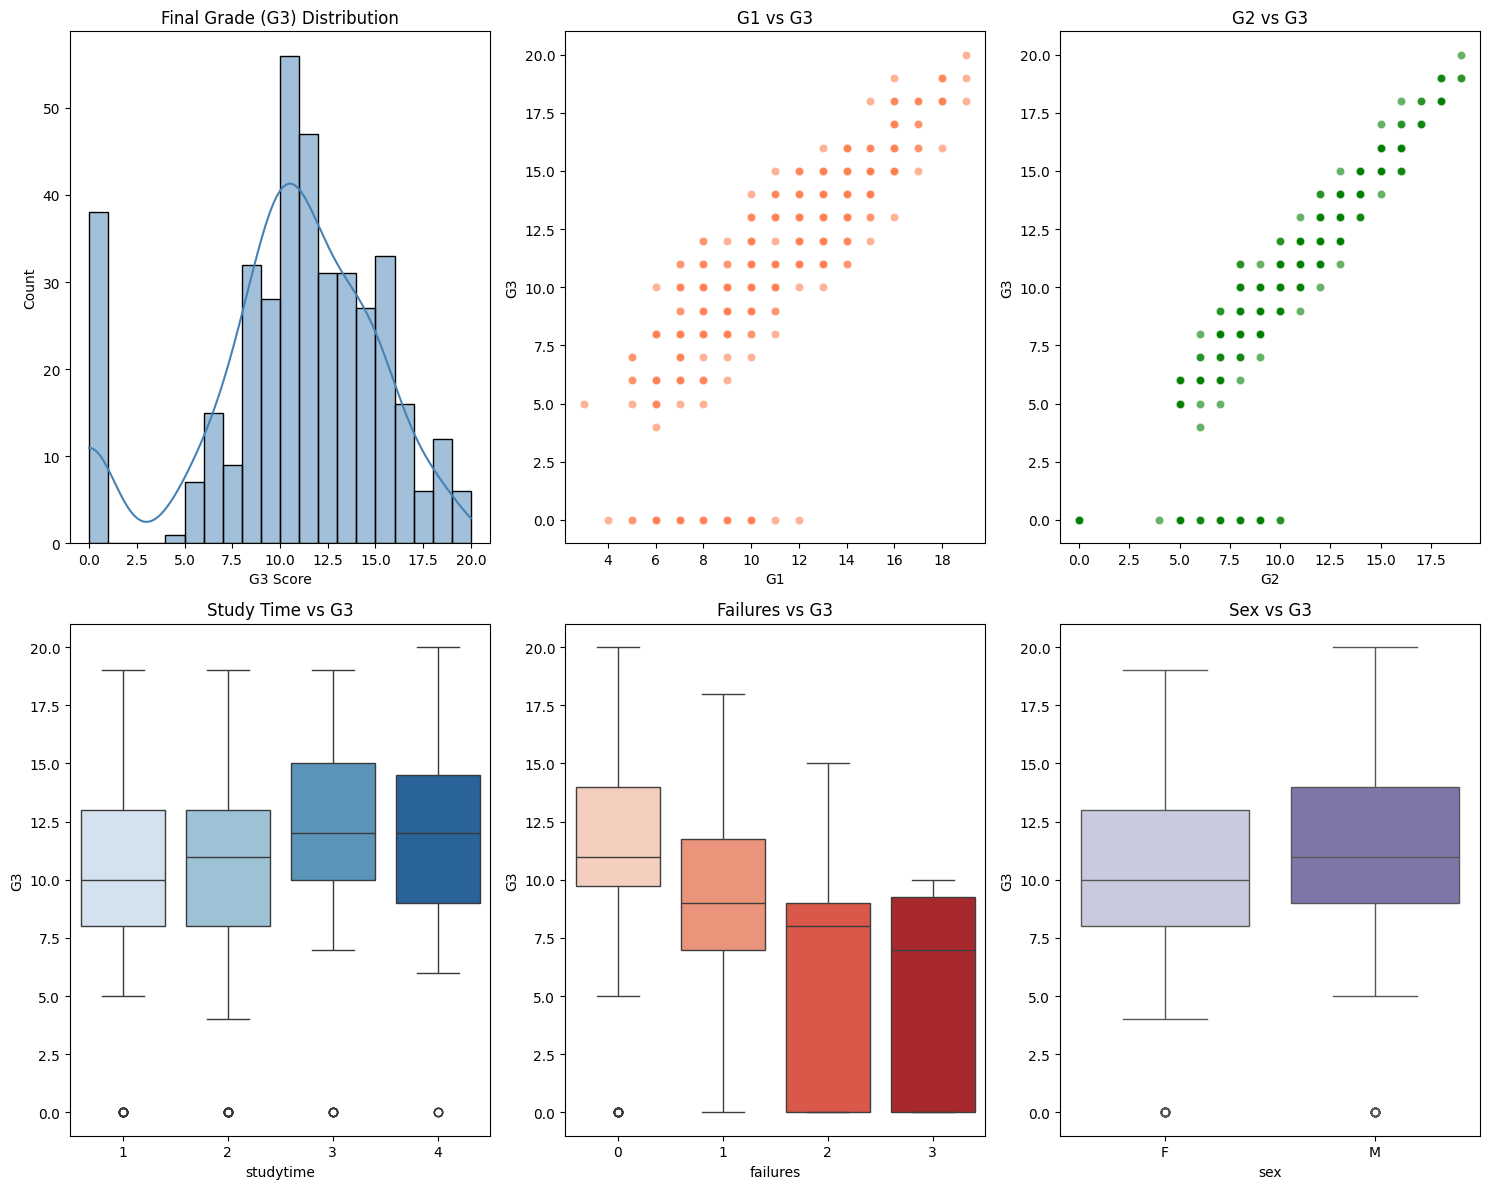

✅ EDA plots saved!


In [6]:
# ── Cell 5 : EDA ──────────────────────────────────────────────────
plt.figure(figsize=(15, 12))

# 1. Target distribution
plt.subplot(2, 3, 1)
sns.histplot(df['G3'], bins=20, color='steelblue', kde=True)
plt.title('Final Grade (G3) Distribution')
plt.xlabel('G3 Score')

# 2. G1, G2, G3 relationship
plt.subplot(2, 3, 2)
sns.scatterplot(data=df, x='G1', y='G3', color='coral', alpha=0.6)
plt.title('G1 vs G3')

plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='G2', y='G3', color='green', alpha=0.6)
plt.title('G2 vs G3')

# 3. Study time vs G3
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='studytime', y='G3', palette='Blues')
plt.title('Study Time vs G3')

# 4. Failures vs G3
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='failures', y='G3', palette='Reds')
plt.title('Failures vs G3')

# 5. Sex vs G3
plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='sex', y='G3', palette='Purples')
plt.title('Sex vs G3')

plt.tight_layout()
plt.savefig('../outputs/eda_plots.png', dpi=150)
plt.show()
print("✅ EDA plots saved!")

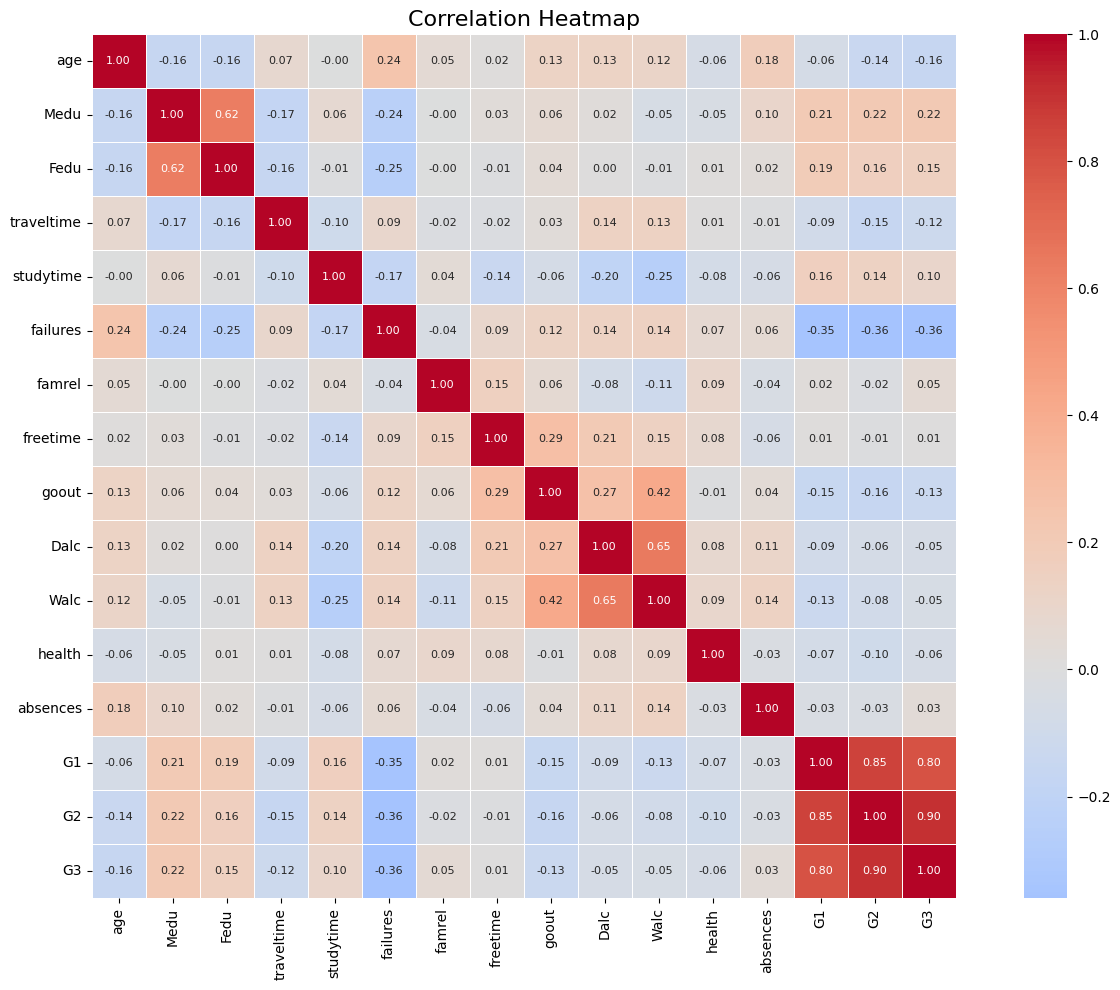

✅ Heatmap saved!


In [7]:
# ── Cell 6 : Correlation Heatmap ──────────────────────────────────
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [8]:
# ── Cell 7 : Preprocessing ────────────────────────────────────────

# Step 1: Encode all object (categorical) columns
df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include='object').columns
print(f"Encoding {len(cat_cols)} categorical columns: {list(cat_cols)}")

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Step 2: Define features and targets
# Regression target  → G3 (score 0-20)
# Classification target → Pass/Fail (G3 >= 10)

X = df_encoded.drop(columns=['G3'])
y_reg   = df_encoded['G3']                          # continuous
y_clf   = (df_encoded['G3'] >= 10).astype(int)      # 1=Pass, 0=Fail

print(f"\nFeatures shape : {X.shape}")
print(f"Regression target (G3) : min={y_reg.min()}, max={y_reg.max()}")
print(f"Classification target  : {y_clf.value_counts().to_dict()}  (0=Fail, 1=Pass)")

# Step 3: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Train/Test split (both tracks use same split)
X_train, X_test, yr_train, yr_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

_, _, yc_train, yc_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42)

print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")
print("✅ Preprocessing done!")

Encoding 17 categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Features shape : (395, 32)
Regression target (G3) : min=0, max=20
Classification target  : {1: 265, 0: 130}  (0=Fail, 1=Pass)

Train size : 316 rows
Test size  : 79 rows
✅ Preprocessing done!


In [9]:
# ── Cell 8 : Regression Track ─────────────────────────────────────
from sklearn.svm import SVR

reg_models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge'               : Ridge(alpha=1.0),
    'Lasso'               : Lasso(alpha=0.1),
    'ElasticNet'          : ElasticNet(alpha=0.1, l1_ratio=0.5),
    'KNN Regressor'       : KNeighborsRegressor(n_neighbors=5),
    'Decision Tree'       : DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostRegressor(n_estimators=100, random_state=42),
    'XGBoost'             : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'SVR'                 : SVR(kernel='rbf', C=1.0)
}

reg_results = []

print("Training Regression Models...\n")
print(f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 50)

for name, model in reg_models.items():
    model.fit(X_train, yr_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    mae  = mean_absolute_error(yr_test, preds)
    r2   = r2_score(yr_test, preds)

    reg_results.append({
        'Model': name, 'RMSE': round(rmse,3),
        'MAE': round(mae,3), 'R²': round(r2,3)
    })
    print(f"{name:<22} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}")

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False).reset_index(drop=True)
print("\n✅ Regression done! Best model:", reg_df.iloc[0]['Model'])

Training Regression Models...

Model                      RMSE      MAE       R²
--------------------------------------------------
Linear Regression         2.243    1.495    0.755
Ridge                     2.242    1.495    0.755
Lasso                     2.134    1.329    0.778
ElasticNet                2.188    1.420    0.767
KNN Regressor             3.367    2.527    0.447
Decision Tree             2.344    1.289    0.732
Random Forest             1.879    1.120    0.828
AdaBoost                  1.993    1.312    0.806
XGBoost                   2.220    1.198    0.760
SVR                       2.607    1.714    0.668

✅ Regression done! Best model: Random Forest


In [10]:
# ── Cell 9 : Classification Track ────────────────────────────────
from sklearn.svm import SVC

clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'KNN Classifier'      : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                          verbosity=0, use_label_encoder=False,
                                          eval_metric='logloss'),
    'SVM'                 : SVC(kernel='rbf', C=1.0, random_state=42)
}

clf_results = []

print("Training Classification Models...\n")
print(f"{'Model':<22} {'Accuracy':>10} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 62)

for name, model in clf_models.items():
    model.fit(X_train, yc_train)
    preds = model.predict(X_test)

    acc  = accuracy_score(yc_test, preds)
    f1   = f1_score(yc_test, preds)
    prec = precision_score(yc_test, preds)
    rec  = recall_score(yc_test, preds)

    clf_results.append({
        'Model': name, 'Accuracy': round(acc,3), 'F1': round(f1,3),
        'Precision': round(prec,3), 'Recall': round(rec,3)
    })
    print(f"{name:<22} {acc:>10.3f} {f1:>8.3f} {prec:>10.3f} {rec:>8.3f}")

clf_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False).reset_index(drop=True)
print("\n✅ Classification done! Best model:", clf_df.iloc[0]['Model'])

Training Classification Models...

Model                    Accuracy       F1  Precision   Recall
--------------------------------------------------------------
Logistic Regression         0.937    0.951      0.961    0.942
KNN Classifier              0.722    0.804      0.750    0.865
Decision Tree               0.937    0.951      0.961    0.942
Random Forest               0.899    0.922      0.940    0.904
AdaBoost                    0.924    0.942      0.942    0.942
XGBoost                     0.873    0.904      0.904    0.904
SVM                         0.873    0.907      0.875    0.942

✅ Classification done! Best model: Logistic Regression


In [11]:
# ── Cell 10 : Results Summary ─────────────────────────────────────
print("=" * 50)
print("   REGRESSION RESULTS (sorted by R²)")
print("=" * 50)
print(reg_df.to_string(index=False))

print("\n")
print("=" * 62)
print("   CLASSIFICATION RESULTS (sorted by F1)")
print("=" * 62)
print(clf_df.to_string(index=False))

   REGRESSION RESULTS (sorted by R²)
            Model  RMSE   MAE    R²
    Random Forest 1.879 1.120 0.828
         AdaBoost 1.993 1.312 0.806
            Lasso 2.134 1.329 0.778
       ElasticNet 2.188 1.420 0.767
          XGBoost 2.220 1.198 0.760
Linear Regression 2.243 1.495 0.755
            Ridge 2.242 1.495 0.755
    Decision Tree 2.344 1.289 0.732
              SVR 2.607 1.714 0.668
    KNN Regressor 3.367 2.527 0.447


   CLASSIFICATION RESULTS (sorted by F1)
              Model  Accuracy    F1  Precision  Recall
Logistic Regression     0.937 0.951      0.961   0.942
      Decision Tree     0.937 0.951      0.961   0.942
           AdaBoost     0.924 0.942      0.942   0.942
      Random Forest     0.899 0.922      0.940   0.904
                SVM     0.873 0.907      0.875   0.942
            XGBoost     0.873 0.904      0.904   0.904
     KNN Classifier     0.722 0.804      0.750   0.865
